# Modern vs Classic Image Format Demand by Country

This notebook analyzes search demand for modern image formats (**WebP**, **AVIF**, **HEIC**) compared to classic legacy formats (**JPG**, **PNG**, **GIF**) across 20 countries using data from the Search Index dataset.

### Core Questions Explored:
1. **Modern vs Classic Demand**: How does the search demand share for WebP + AVIF + HEIC compare with JPG + PNG + GIF per country?
2. **HEIC Adoption & Friction**: Which countries search most for HEIC (identifying where iPhone photos cause the most "how do I open this" moments)?
3. **12-Month Trends**: How have search volumes for WebP and AVIF evolved over the past 12 months?

*Note: All country-level analyses exclude the worldwide (`WW`) aggregate scope to ensure clean per-country comparisons.*

## Load the Data

Load `popularity-formats-summary.csv` and `popularity-formats-monthly.csv`. The path check below supports running the notebook from either the repository root or the `notebooks/` directory.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Matplotlib configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "sans-serif"]

# Locate summary CSV
summary_path = Path("data/popularity/csv/popularity-formats-summary.csv")
if not summary_path.exists():
    summary_path = Path("../data/popularity/csv/popularity-formats-summary.csv")
if not summary_path.exists():
    raise FileNotFoundError("Could not find popularity-formats-summary.csv")

# Locate monthly CSV
monthly_path = Path("data/popularity/csv/popularity-formats-monthly.csv")
if not monthly_path.exists():
    monthly_path = Path("../data/popularity/csv/popularity-formats-monthly.csv")
if not monthly_path.exists():
    raise FileNotFoundError("Could not find popularity-formats-monthly.csv")

df_summary = pd.read_csv(summary_path)
df_monthly = pd.read_csv(monthly_path)

print(f"Summary rows: {len(df_summary)}, Monthly rows: {len(df_monthly)}")
df_summary.head(6)

Summary rows: 252, Monthly rows: 2880


,snapshot,category,scope,rank,brand,vendor,avg_monthly_searches,share_pct,mom_pct,yoy_pct
0,2026-09,formats,WW,1,PDF,Document,2826700,37.0,4.6,-5.3
1,2026-09,formats,WW,2,GIF,Animation,2545300,33.3,16.0,-22.7
2,2026-09,formats,WW,3,PNG,Raster image,631300,8.3,7.8,-16.9
3,2026-09,formats,WW,4,JPG,Raster image,534100,7.0,10.3,-6.4
4,2026-09,formats,WW,5,PSD,Photoshop,351800,4.6,31.7,48.2
5,2026-09,formats,WW,6,SVG,Vector image,165800,2.2,-7.3,-7.9


## Dataset Overview & Country Mapping

Extract the country code mapping from the monthly dataset and filter the summary data to country scopes only.

In [2]:
# Extract country code to country name mapping
country_names = df_monthly[["country_code", "country"]].drop_duplicates().set_index("country_code")["country"].to_dict()

# Filter summary dataset to individual countries (excluding worldwide 'WW')
df_countries = df_summary[df_summary["scope"] != "WW"].copy()
df_countries["country_name"] = df_countries["scope"].map(country_names)

print(f"Number of country scopes: {df_countries['scope'].nunique()}")
print(f"Formats evaluated: {sorted(df_countries['brand'].unique())}")

Number of country scopes: 20
Formats evaluated: ['AVIF', 'BMP', 'GIF', 'HEIC', 'ICO', 'JPG', 'PDF', 'PNG', 'PSD', 'SVG', 'TIFF', 'WebP']


## 1. Modern vs Classic Format Demand by Country

We group formats into:
- **Modern Formats**: WebP, AVIF, HEIC
- **Classic Formats**: JPG, PNG, GIF

We calculate total monthly searches for both categories per country, and determine the modern search demand share:
$$\\text{Modern Share} = \\frac{\\text{Modern Searches}}{\\text{Modern Searches} + \\text{Classic Searches}} \\times 100\\%$$

In [3]:
modern_formats = ["WebP", "AVIF", "HEIC"]
classic_formats = ["JPG", "PNG", "GIF"]

# Aggregate searches per country
modern_searches = df_countries[df_countries["brand"].isin(modern_formats)].groupby("scope")["avg_monthly_searches"].sum()
classic_searches = df_countries[df_countries["brand"].isin(classic_formats)].groupby("scope")["avg_monthly_searches"].sum()

comparison_df = pd.DataFrame({
    "country_name": [country_names.get(s, s) for s in modern_searches.index],
    "modern_searches": modern_searches,
    "classic_searches": classic_searches,
})
comparison_df["total_image_searches"] = comparison_df["modern_searches"] + comparison_df["classic_searches"]
comparison_df["modern_share_pct"] = (comparison_df["modern_searches"] / comparison_df["total_image_searches"] * 100).round(2)
comparison_df["classic_share_pct"] = (100 - comparison_df["modern_share_pct"]).round(2)
comparison_df = comparison_df.sort_values("modern_share_pct", ascending=False)

comparison_df[["country_name", "modern_searches", "classic_searches", "modern_share_pct", "classic_share_pct"]].reset_index()

,scope,country_name,modern_searches,classic_searches,modern_share_pct,classic_share_pct
0,JP,Japan,42800,197900,17.78,82.22
1,KR,South Korea,7600,42400,15.20,84.80
2,DE,Germany,8800,96000,8.40,91.60
3,SG,Singapore,1330,14700,8.30,91.70
4,IT,Italy,4590,59200,7.20,92.80
5,PL,Poland,5180,69700,6.92,93.08
6,NL,Netherlands,2890,50300,5.43,94.57
7,FR,France,9600,168600,5.39,94.61
8,ID,Indonesia,5390,114100,4.51,95.49
9,ES,Spain,3920,83400,4.49,95.51


### Visualizing Modern vs Classic Demand Share

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


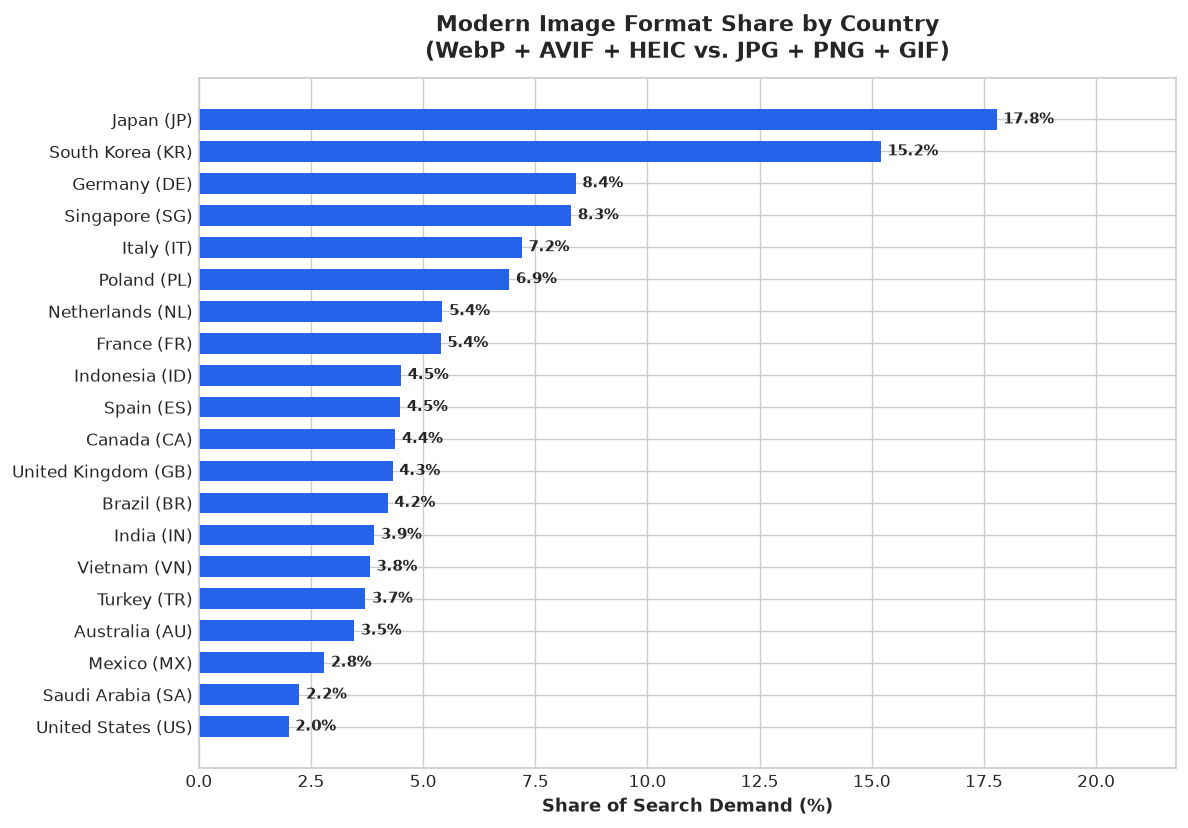

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

countries_sorted = comparison_df.sort_values("modern_share_pct", ascending=True)
y_pos = range(len(countries_sorted))

bars = ax.barh(y_pos, countries_sorted["modern_share_pct"], color="#2563eb", height=0.65, label="Modern (WebP + AVIF + HEIC)")
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{c} ({s})" for c, s in zip(countries_sorted["country_name"], countries_sorted.index)])
ax.set_xlabel("Share of Search Demand (%)", fontsize=11, fontweight="bold")
ax.set_title("Modern Image Format Share by Country\n(WebP + AVIF + HEIC vs. JPG + PNG + GIF)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, max(countries_sorted["modern_share_pct"]) + 4)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f"{width:.1f}%",
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left", va="center", fontsize=9, fontweight="semibold")

plt.tight_layout()
plt.show()

### Key Observations: Modern Format Demand
- **Japan (`JP`)** and **South Korea (`KR`)** exhibit the highest modern image format search shares at **17.8%** and **15.2%**, respectively.
- **European Markets** such as Germany (8.4%), Italy (7.2%), Poland (6.9%), and France (5.4%) show moderate adoption.
- In larger high-volume markets like the United States (2.0%) and Mexico (2.8%), massive search volumes for legacy formats (especially GIF and JPG) dominate overall image format interest.

## 2. Where Do Users Search Most for HEIC?

HEIC is Apple's default image container format for iPhone photos. Because HEIC has limited native playback and editing compatibility on legacy Windows and older systems, search queries for HEIC frequently reflect users needing converters or viewers ("how do I open a HEIC file?").

We evaluate:
1. **Absolute Search Volume**: The raw number of average monthly searches.
2. **Relative Search Share**: HEIC searches as a percentage of overall format search volume in that country.

In [5]:
heic_data = df_countries[df_countries["brand"] == "HEIC"].copy()
heic_data = heic_data.sort_values("avg_monthly_searches", ascending=False)
heic_top = heic_data[["scope", "country_name", "avg_monthly_searches", "share_pct"]].reset_index(drop=True)
heic_top.columns = ["Code", "Country", "Monthly Searches", "Share of Total Formats (%)"]
heic_top.head(10)

,Code,Country,Monthly Searches,Share of Total Formats (%)
0,JP,Japan,18100,3.4
1,US,United States,14800,0.6
2,IN,India,6600,0.6
3,FR,France,5400,1.7
4,BR,Brazil,3600,0.6
5,DE,Germany,3600,1.5
6,CA,Canada,2900,1.2
7,GB,United Kingdom,2900,1.1
8,PL,Poland,2400,1.8
9,IT,Italy,2400,1.4


### Visualizing HEIC Search Volumes and Shares

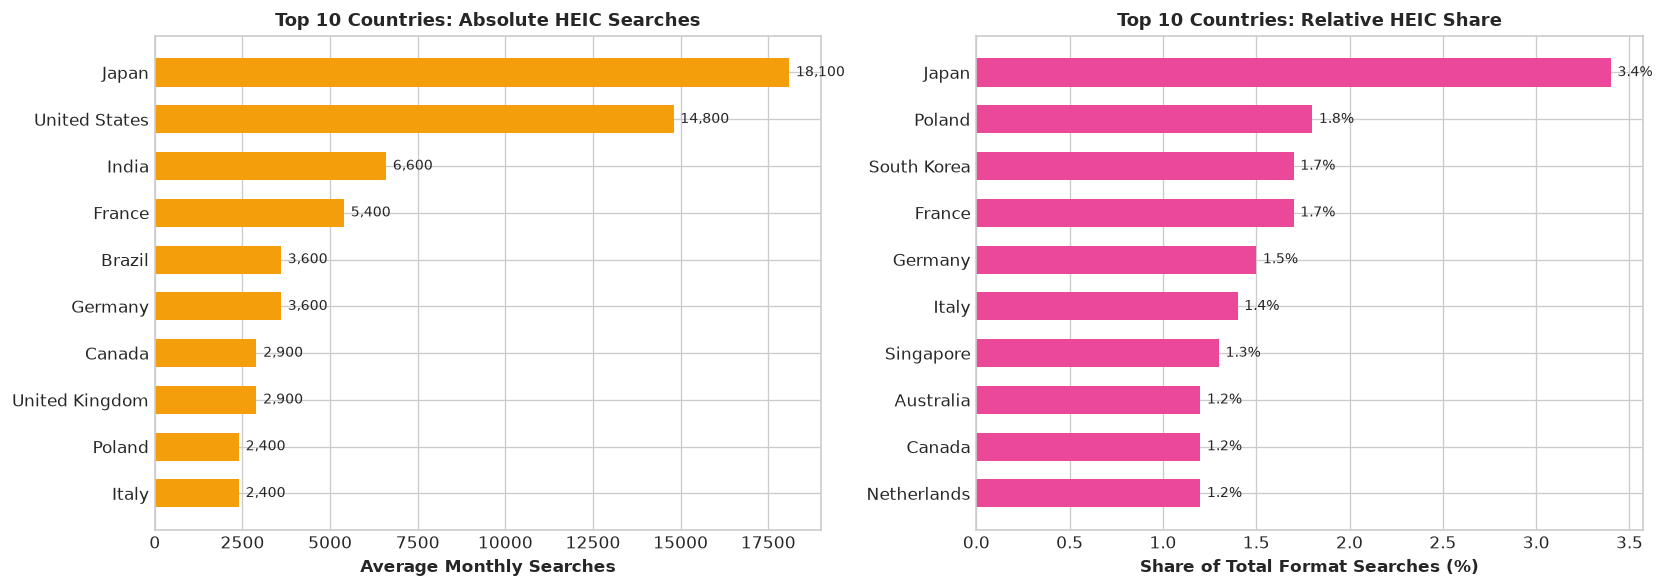

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 by absolute search volume
top_abs = heic_data.sort_values("avg_monthly_searches", ascending=True).tail(10)
y1 = range(len(top_abs))
ax1.barh(y1, top_abs["avg_monthly_searches"], color="#f59e0b", height=0.6)
ax1.set_yticks(y1)
ax1.set_yticklabels(top_abs["country_name"])
ax1.set_xlabel("Average Monthly Searches", fontweight="bold")
ax1.set_title("Top 10 Countries: Absolute HEIC Searches", fontweight="bold", fontsize=11)
for i, v in enumerate(top_abs["avg_monthly_searches"]):
    ax1.annotate(f"{v:,}", (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8.5)

# Top 10 by relative share of total format searches
top_share = heic_data.sort_values("share_pct", ascending=True).tail(10)
y2 = range(len(top_share))
ax2.barh(y2, top_share["share_pct"], color="#ec4899", height=0.6)
ax2.set_yticks(y2)
ax2.set_yticklabels(top_share["country_name"])
ax2.set_xlabel("Share of Total Format Searches (%)", fontweight="bold")
ax2.set_title("Top 10 Countries: Relative HEIC Share", fontweight="bold", fontsize=11)
for i, v in enumerate(top_share["share_pct"]):
    ax2.annotate(f"{v:.1f}%", (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8.5)

plt.tight_layout()
plt.show()

### Key Observations: HEIC Friction Hotspots
- **Japan** is #1 globally in both absolute search volume (**18,100 monthly searches**) and relative share (**3.4%** of total format queries), surpassing even the United States (**14,800 searches**). This directly reflects Japan's high iPhone penetration coupled with frequent desktop Windows usage.
- **European countries** including Poland (1.8%), France (1.7%), and Germany (1.5%) also exhibit strong relative HEIC interest, showing that cross-device compatibility remains a common user challenge across these regions.

## 3. 12-Month Trends: WebP vs AVIF

WebP and AVIF are the two main modern web image formats:
- **WebP**: Introduced by Google, currently enjoys widespread browser and CMS support.
- **AVIF**: Newer standard based on AV1, boasting superior compression and color depth, but currently undergoing an adoption ramp.

Here we track the monthly aggregate search volume for both formats across the 20 monitored countries from September 2025 to August 2026.

In [7]:
# Aggregate monthly searches across the 20 tracked countries
webp_monthly = df_monthly[df_monthly["brand"] == "WebP"].groupby("year_month")["searches"].sum()
avif_monthly = df_monthly[df_monthly["brand"] == "AVIF"].groupby("year_month")["searches"].sum()

trend_df = pd.DataFrame({
    "WebP": webp_monthly,
    "AVIF": avif_monthly,
})
trend_df["WebP_to_AVIF_Ratio"] = (trend_df["WebP"] / trend_df["AVIF"]).round(2)
trend_df

,WebP,AVIF,WebP_to_AVIF_Ratio
year_month,,,
2025-09,76840,28230,2.72
2025-10,74410,27900,2.67
2025-11,74610,30400,2.45
2025-12,72210,26520,2.72
2026-01,77180,28970,2.66
2026-02,67650,25580,2.64
2026-03,76940,28900,2.66
2026-04,73210,27080,2.70
2026-05,77710,25100,3.10


### Visualizing the 12-Month Trajectory

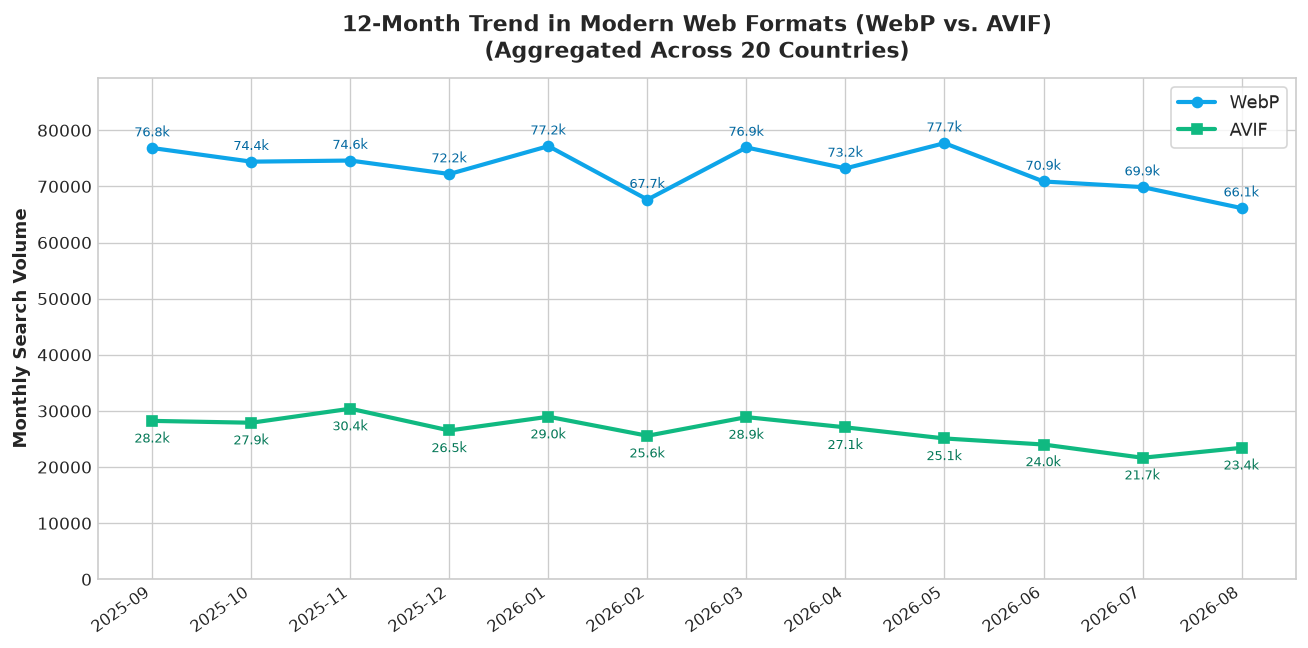

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))

months = trend_df.index
x = range(len(months))

ax.plot(x, trend_df["WebP"], marker="o", linewidth=2.5, color="#0ea5e9", label="WebP", markersize=6)
ax.plot(x, trend_df["AVIF"], marker="s", linewidth=2.5, color="#10b981", label="AVIF", markersize=6)

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=35, ha="right", fontsize=9.5)
ax.set_ylabel("Monthly Search Volume", fontsize=11, fontweight="bold")
ax.set_title("12-Month Trend in Modern Web Formats (WebP vs. AVIF)\n(Aggregated Across 20 Countries)", fontsize=13, fontweight="bold", pad=12)
ax.legend(frameon=True, loc="upper right", fontsize=11)
ax.set_ylim(0, max(trend_df["WebP"]) * 1.15)

for i, (w_val, a_val) in enumerate(zip(trend_df["WebP"], trend_df["AVIF"])):
    ax.annotate(f"{w_val/1000:.1f}k", (i, w_val), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8, color="#0369a1")
    ax.annotate(f"{a_val/1000:.1f}k", (i, a_val), xytext=(0, -13), textcoords="offset points", ha="center", fontsize=8, color="#047857")

plt.tight_layout()
plt.show()

### Key Observations: WebP vs AVIF Trend
- **Persistent Multiplier**: WebP consistently records **2.5x to 3.1x** higher search volume than AVIF across all 12 months.
- **Baseline Stability**: AVIF shows an established baseline of ~22k–30k monthly searches across the 20 countries, while WebP fluctuates between ~66k and ~78k searches.
- **Seasonality**: Both formats reflect similar seasonal patterns, peaking during the late autumn and winter developer cycles, and dipping slightly in summer.

## Summary & Conclusions

1. **Modern Format Adoption**:
   - Modern image formats account for an average of 4–6% of image searches globally, but regional adoption varies dramatically.
   - East Asian nations lead by far: Japan (17.8%) and South Korea (15.2%) have the highest share of modern image format queries.
2. **HEIC Friction**:
   - Japan produces the most absolute HEIC searches globally (18,100/month), ahead of the US.
   - Relative HEIC interest is particularly prominent in Japan (3.4%), Poland (1.8%), France (1.7%), and Germany (1.5%), indicating where iPhone users most frequently seek help opening or converting their photos.
3. **WebP vs AVIF Dynamics**:
   - WebP remains the dominant modern web format in developer search volume by roughly 3:1 over AVIF.
   - Both formats have established stable, consistent search volumes over the past 12 months with no sudden declines.